In [1]:
import numpy as np
import pandas as pd
import sim_pcca_fa as spf
import pcca_fa_mdl as pf
import matplotlib.pyplot as plt
from timeit import default_timer as timer

early_stop = False
n_trials = 10000
xDim,yDim = 30,30
zDim,zxDim,zyDim = 1,1,1
rand_seed = 10
zDim_list = np.linspace(0,5,6)

# simulate from a factor analysis model
pf_simulator = spf.sim_pcca_fa(xDim,yDim,\
    zDim,zxDim,zyDim,rand_seed=rand_seed)
X,Y = pf_simulator.sim_data(n_trials,rand_seed=rand_seed)
sim_params = pf_simulator.get_params()

# train model
model = pf.pcca_fa()
LL,testLL = model.train(X,Y,zDim,zxDim,zyDim)

# # cross-validation
# start = timer()
# LL_curves = model.crossvalidate(X,Y,early_stop=early_stop,rand_seed=rand_seed,verbose=True,tol=1e-4, \
#                                 zDim_list=zDim_list,zxDim_list=zDim_list,zyDim_list=zDim_list)
# end = timer()
# cv_z,cv_zx,cv_zy = LL_curves['zDim'],LL_curves['zxDim'],LL_curves['zyDim']
# print(f'{end-start} seconds elapsed...')
# print(f'Z: {cv_z:d}, Zx: {cv_zx:d}, Zy: {cv_zy:d}')


Crossvalidating percent shared variance...
   Bootstrap sample  1  of  50 ...
   Bootstrap sample  2  of  50 ...
   Bootstrap sample  3  of  50 ...
   Bootstrap sample  4  of  50 ...
   Bootstrap sample  5  of  50 ...
   Bootstrap sample  6  of  50 ...
   Bootstrap sample  7  of  50 ...
   Bootstrap sample  8  of  50 ...
   Bootstrap sample  9  of  50 ...
   Bootstrap sample  10  of  50 ...
   Bootstrap sample  11  of  50 ...
   Bootstrap sample  12  of  50 ...
   Bootstrap sample  13  of  50 ...
   Bootstrap sample  14  of  50 ...
   Bootstrap sample  15  of  50 ...
   Bootstrap sample  16  of  50 ...
   Bootstrap sample  17  of  50 ...
   Bootstrap sample  18  of  50 ...
   Bootstrap sample  19  of  50 ...
   Bootstrap sample  20  of  50 ...
   Bootstrap sample  21  of  50 ...
   Bootstrap sample  22  of  50 ...
   Bootstrap sample  23  of  50 ...
   Bootstrap sample  24  of  50 ...
   Bootstrap sample  25  of  50 ...
   Bootstrap sample  26  of  50 ...
   Bootstrap sample  27  of  5

Text(0.5, 1.0, 'area Y, local')

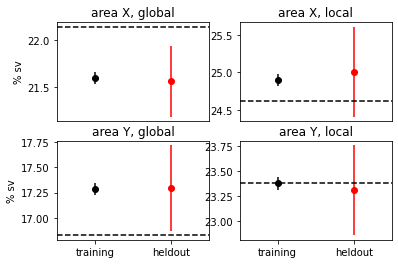

In [11]:
# compute metrics
sim_model = pf.pcca_fa()
sim_model.set_params(sim_params)
true_psv = sim_model.compute_metrics(cutoff_thresh=0.95)['psv']

train_psv,test_psv = model.compute_cv_psv(X,Y,zDim,zxDim,zyDim,n_boots=50,\
    rand_seed=rand_seed,return_each=True,test_size=0.1,early_stop=early_stop,verbose=True)

fig,ax = plt.subplots(2,2)

ax[0,0].errorbar(1,np.mean(train_psv['psv_x']),yerr=np.std(train_psv['psv_x']),fmt='ko',label='training')
ax[0,0].errorbar(2,np.mean(test_psv['psv_x']),yerr=np.std(test_psv['psv_x']),fmt='ro',label='heldout')
ax[0,0].set_xlim([0.5,2.5])
ax[0,0].plot(ax[0,0].get_xlim(),np.ones(2)*true_psv['psv_x'],'k--',label='true')
ax[0,0].set_ylabel('% sv')
ax[0,0].set_xticks([])
ax[0,0].set_title('area X, global')

ax[0,1].errorbar(1,np.mean(train_psv['psv_priv_x']),yerr=np.std(train_psv['psv_priv_x']),fmt='ko',label='training')
ax[0,1].errorbar(2,np.mean(test_psv['psv_priv_x']),yerr=np.std(test_psv['psv_priv_x']),fmt='ro',label='heldout')
ax[0,1].set_xlim([0.5,2.5])
ax[0,1].plot(ax[0,1].get_xlim(),np.ones(2)*true_psv['psv_priv_x'],'k--',label='true')
ax[0,1].set_xticks([])
ax[0,1].set_title('area X, local')

ax[1,0].errorbar(1,np.mean(train_psv['psv_y']),yerr=np.std(train_psv['psv_y']),fmt='ko',label='training')
ax[1,0].errorbar(2,np.mean(test_psv['psv_y']),yerr=np.std(test_psv['psv_y']),fmt='ro',label='heldout')
ax[1,0].set_xlim([0.5,2.5])
ax[1,0].plot(ax[1,0].get_xlim(),np.ones(2)*true_psv['psv_y'],'k--',label='true')
ax[1,0].set_ylabel('% sv')
ax[1,0].set_xticks([1,2])
ax[1,0].set_xticklabels(['training','heldout'])
ax[1,0].set_title('area Y, global')

ax[1,1].errorbar(1,np.mean(train_psv['psv_priv_y']),yerr=np.std(train_psv['psv_priv_y']),fmt='ko',label='training')
ax[1,1].errorbar(2,np.mean(test_psv['psv_priv_y']),yerr=np.std(test_psv['psv_priv_y']),fmt='ro',label='heldout')
ax[1,1].set_xlim([0.5,2.5])
ax[1,1].plot(ax[1,1].get_xlim(),np.ones(2)*true_psv['psv_priv_y'],'k--',label='true')
ax[1,1].set_xticks([1,2])
ax[1,1].set_xticklabels(['training','heldout'])
ax[1,1].set_title('area Y, local')

Text(0.5, 1.0, 'both areas, local')

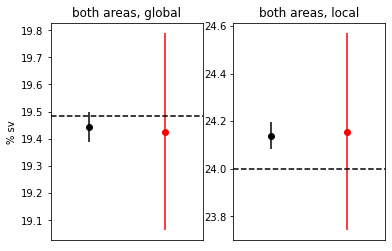

In [12]:
# make plots for across and within combining
fig,ax = plt.subplots(1,2)

ax[0].errorbar(1,np.mean(train_psv['psv_all']),yerr=np.std(train_psv['psv_all']),fmt='ko',label='training')
ax[0].errorbar(2,np.mean(test_psv['psv_all']),yerr=np.std(test_psv['psv_all']),fmt='ro',label='heldout')
ax[0].set_xlim([0.5,2.5])
ax[0].plot(ax[0].get_xlim(),np.ones(2)*true_psv['psv_all'],'k--',label='true')
ax[0].set_ylabel('% sv')
ax[0].set_xticks([])
ax[0].set_title('both areas, global')

ax[1].errorbar(1,np.mean(train_psv['psv_priv_all']),yerr=np.std(train_psv['psv_priv_all']),fmt='ko',label='training')
ax[1].errorbar(2,np.mean(test_psv['psv_priv_all']),yerr=np.std(test_psv['psv_priv_all']),fmt='ro',label='heldout')
ax[1].set_xlim([0.5,2.5])
ax[1].plot(ax[1].get_xlim(),np.ones(2)*true_psv['psv_priv_all'],'k--',label='true')
ax[1].set_xticks([])
ax[1].set_title('both areas, local')

In [13]:
# compute correlations
print(model.get_params()['rho'])
z,LL = model.estep(X,Y)
zx,zy = z['zx_mu'],z['zy_mu']

[0.94781422]


In [17]:
# megan
# samples
mu_x,mu_y = X.mean(axis=0),Y.mean(axis=0)
Xc,Yc = (X-mu_x), (Y-mu_y)
sampleCov_x = 1/n_trials * (Xc.T).dot(Xc)
sampleCov_y = 1/n_trials * (Yc.T).dot(Yc)

# gt
wx = sim_params['W_x']
wy = sim_params['W_y']
lx = sim_params['L_x']
ly = sim_params['L_y']
psix = sim_params['psi_x']
psiy = sim_params['psi_y']

wwt_gt_x = wx @ np.transpose(wx)
llt_gt_x = lx @ np.transpose(lx)
gtCov_x = np.diag(wwt_gt_x + llt_gt_x) + psix
wwt_gt_y = wy @ np.transpose(wy)
llt_gt_y = ly @ np.transpose(ly)
gtCov_y = np.diag(wwt_gt_y + llt_gt_y) + psiy

print(sampleCov_x - gtCov_x)
print(sampleCov_y - gtCov_y)

[[ 8.50205483e-03 -2.39922862e+00 -7.70105712e+00 -1.14056369e+01
  -5.18563089e+00 -3.55641720e+00 -4.06333737e+00 -6.08334694e+00
  -8.42132071e+00 -2.42492752e+00 -4.23684763e+00 -2.43405344e+00
  -2.60620071e-01 -1.80072787e+00 -1.89342996e+00 -6.94013920e+00
  -5.86172961e+00 -4.89800976e+00 -8.21784877e+00 -4.10675315e+00
  -8.15214341e+00 -6.44304861e+00 -3.24554671e+00 -4.04117494e+00
  -1.74323631e+00 -1.10655001e+01 -2.35801728e+00 -3.99634779e+00
  -4.43548993e+00 -8.11528319e+00]
 [-1.37898311e+00  5.20995544e-02 -8.99585337e+00 -1.31568111e+01
  -6.23543685e+00 -3.70821223e+00 -5.08210105e+00 -5.85583522e+00
  -9.60461292e+00 -2.90070714e+00 -4.16889005e+00 -1.71860782e+00
   2.81580269e-01 -2.28570094e+00 -1.02314166e+00 -7.38243338e+00
  -6.47834413e+00 -5.11972762e+00 -9.46343558e+00 -5.04609441e+00
  -8.45474377e+00 -5.83221156e+00 -2.73480008e+00 -3.64689734e+00
  -2.00793321e+00 -1.16860237e+01 -1.50095829e+00 -3.80209652e+00
  -4.78117910e+00 -8.50898828e+00]
 [-3.1

In [42]:
# megan
N=10000
# try to create generative model
# from byrons notes:
# step 1: draw z from N(0,I)
# z = np.random.normal(loc=0.0, scale=1.0, size=(1,N))
z = np.random.randn(1, N)

highd_z = wx @ z
epsilon = np.random.normal(loc=0.0, scale=np.sqrt(psix), size=(30,1))
mu_x = mu_x.reshape(xDim,1)

x = highd_z + mu_x + epsilon

mu_x_test = np.mean(x, axis=1)
mu_x_test = mu_x_test.reshape(xDim,1)
Xc = (x-mu_x_test)
sampleCov_x = 1/N * (Xc).dot(Xc.T)



In [54]:
modelcov = (wwt_gt_y + np.diag(psiy))
test = sampleCov_y - modelcov
print(test)

[[ 1.28813919e-01  2.02711804e-01  6.67845108e-01  2.92240453e-01
  -1.44310106e-01 -3.09029726e-02 -3.33522287e-01  2.57250351e-01
   4.02184682e-01 -1.32583181e+00  6.22337620e-01  8.84301811e-02
   2.77005518e-01  2.88768960e-01 -1.15836186e+00 -5.50678590e-01
  -1.38655091e-01 -4.21411001e-01  1.36388007e-01 -1.70218361e-01
  -8.67838553e-01  3.32517630e-01  3.73862543e-01  3.09702275e-01
  -2.76518506e-01 -7.95391425e-02  2.77161042e-01  2.92403076e-01
   4.87652080e-01  5.00258121e-03]
 [ 2.02711804e-01  1.60032244e-01  5.57793022e-01  2.05856729e-01
  -1.00573854e-01  2.60306898e-02 -2.98232953e-01  2.25086510e-01
   4.20275933e-01 -1.21043542e+00  5.07222480e-01 -4.01116656e-02
   1.94058067e-01  2.69310166e-01 -9.68243337e-01 -4.80279195e-01
  -1.43518106e-01 -3.32286919e-01  1.21642879e-01 -2.11966166e-01
  -7.02006754e-01  2.52343207e-01  4.31988203e-01  2.25359338e-01
  -2.99417596e-01 -1.17113345e-01  2.20512248e-01  2.45819430e-01
   4.00323242e-01 -1.26928287e-01]
 [ 6.6